# Semana 8 — MDP de horizonte infinito: Iteración de Valor (VI) e Iteración de Política (PI)


`jmarkov` es la **herramienta principal** de este módulo del curso: en cuanto tenemos un MDP planteado (estados, acciones, matrices de transición, retornos, $\gamma$), `dtmdp` lo resuelve directamente, con el método que le pidamos.

Eso no significa que programar VI y PI con ciclos sea inútil: es la única forma de entender *qué* calcula `dtmdp` por dentro. Por eso en este cuaderno **abrimos la caja negra una sola vez**, en el Ejercicio 1: implementamos VI y PI a mano, paso por paso, y confirmamos que reproducen exactamente lo que hace `jmarkov`. De ahí en adelante —Ejercicio 2 y el ejercicio abierto— resolvemos **directamente con `jmarkov`**, como hará usted de aquí en adelante en el curso: no volvemos a escribir el ciclo de VI ni el de PI.

### Convenciones de programación

- arreglos de NumPy, ciclos `for`, condicionales `if`, funciones sencillas (para construir el modelo: estados, acciones, matrices, retornos);
- `np.max`, `np.argmax`;
- `np.linalg.solve`, usado una sola vez, dentro de la implementación manual de PI;
- `jmarkov` (`dtmdp`) como la herramienta con la que efectivamente **resolvemos** los MDP de este cuaderno, salvo la única vez que los resolvemos a mano para entender el mecanismo.

### `jmarkov.mdp.dtmdp`: la interfaz que vamos a usar todo el cuaderno

```python
from jmarkov.mdp.dtmdp import dtmdp

proceso = dtmdp(estados, acciones, {accion: matriz}, R, gamma)
V, politica = proceso.solve(tolerancia, minimize=False, method="value_iteration")
```

| Argumento | Estructura | Comentario |
|:--|:--|:--|
| `estados`, `acciones` | `np.array` de etiquetas | Las etiquetas de `acciones` **sí** se usan: son las claves del diccionario de política que devuelve `solve` |
| tercer argumento | diccionario `{accion: matriz}` | Una matriz $n\times n$ por cada acción |
| `R` | arreglo `(n_estados, n_acciones)` | `R[i, a]` = retorno de la acción `a` en el estado `i` |
| `gamma` | `float` en $[0,1)$ | Estrictamente menor que 1 |

`solve` devuelve dos objetos: `V`, indexado **por posición** (igual que un arreglo de NumPy cualquiera), y `politica`, un **diccionario por etiqueta** de estado. El argumento `method` acepta `"value_iteration"` o `"policy_iteration"`: como programaremos los dos a mano, podremos pedirle a `jmarkov` que resuelva con cada uno por separado y comparar cada algoritmo contra su propia implementación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from jmarkov.mdp.dtmdp import dtmdp

np.set_printoptions(precision=4, suppress=True)

## Fundamentos teóricos

### Ecuación de Bellman de optimalidad

Para un MDP $(\mathcal S,\mathcal A,P,r,\gamma)$ con $\gamma<1$:

$$
V^*(s) = \max_{a\in\mathcal A}\left[ r(s,a) + \gamma \sum_{s'} P(s'\mid s,a)\, V^*(s') \right].
$$

### Iteración de Valor (VI)

Partimos de $V^{(0)}$ (típicamente $\mathbf 0$) y aplicamos el operador de Bellman repetidamente:

$$
V^{(k+1)}(s) = \max_a \left[ r(s,a) + \gamma \sum_{s'} P(s'\mid s,a)\, V^{(k)}(s') \right],
$$

hasta que $\|V^{(k+1)}-V^{(k)}\|_\infty$ sea suficientemente pequeño. La política óptima se obtiene tomando el `argmax` de la última actualización. Esto es exactamente lo que hace `dtmdp.solve(..., method="value_iteration")`.

### Iteración de Política (PI)

Alterna dos pasos, empezando de una política arbitraria $\pi^{(0)}$:

1. **Evaluación exacta:** resolver $(I-\gamma P^{\pi^{(k)}})V^{\pi^{(k)}} = r^{\pi^{(k)}}$ (el mismo sistema lineal de la Semana 6).
2. **Mejora:** $\pi^{(k+1)}(s) = \arg\max_a\left[r(s,a)+\gamma\sum_{s'}P(s'\mid s,a)V^{\pi^{(k)}}(s')\right]$.

Se detiene cuando la política deja de cambiar. Esto es lo que hace `dtmdp.solve(..., method="policy_iteration")`.

## Herramienta: `np.argmax`

Para cada estado calculamos un valor por acción. Necesitamos distinguir el mayor valor (`np.max`) de la posición donde ocurre (`np.argmax`), que es la acción óptima.

In [2]:
valores_ejemplo = np.array([4.2, 6.8])
print("Mejor valor:", np.max(valores_ejemplo))
print("Índice de la mejor acción:", np.argmax(valores_ejemplo))

Mejor valor: 6.8
Índice de la mejor acción: 1


---
# Ejercicio 1 — Gestión de activos: reemplazo de un generador

*(En este ejercicio, y solo en este, abrimos la caja negra: implementamos VI y PI a mano antes de usar `jmarkov`.)*

Energía Andes S.A.S. observa el estado de un generador y decide entre **Mantener** y **Reemplazar**.

$$
\mathcal S=\{\text{Nuevo},\text{Bueno},\text{Regular},\text{Malo}\}, \qquad \mathcal A=\{\text{Mantener},\text{Reemplazar}\}.
$$

$$
P^{(M)}=\begin{pmatrix}0.85&0.15&0&0\\0&0.80&0.20&0\\0&0&0.70&0.30\\0&0&0&1\end{pmatrix}, \qquad P^{(R)}=\begin{pmatrix}1&0&0&0\\0.85&0.15&0&0\\0.85&0.15&0&0\\0.85&0.15&0&0\end{pmatrix}.
$$

La primera fila de $P^{(R)}$ es una transición ficticia válida: Reemplazar desde Nuevo se hace infactible mediante una recompensa muy negativa.

| Estado | Mantener | Reemplazar |
|:---|---:|---:|
| Nuevo | 100 | -10000 |
| Bueno | 80 | -20 |
| Regular | 50 | -20 |
| Malo | 20 | -20 |

Factor de descuento: $\gamma=0.90$.

In [3]:
estados_generador = np.array(["Nuevo", "Bueno", "Regular", "Malo"])
acciones_generador = np.array(["Mantener", "Reemplazar"])
gamma_generador = 0.90

P_mantener = np.array([
    [0.85, 0.15, 0.00, 0.00],
    [0.00, 0.80, 0.20, 0.00],
    [0.00, 0.00, 0.70, 0.30],
    [0.00, 0.00, 0.00, 1.00]
])

P_reemplazar = np.array([
    [1.00, 0.00, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00],
    [0.85, 0.15, 0.00, 0.00]
])

# indice 0 -> "Mantener", indice 1 -> "Reemplazar"
matrices_generador = [P_mantener, P_reemplazar]

retornos_generador = np.array([
    [100.0, -10000.0],
    [ 80.0,    -20.0],
    [ 50.0,    -20.0],
    [ 20.0,    -20.0]
])

numero_estados_generador = len(estados_generador)
numero_acciones_generador = len(acciones_generador)

# Verificacion barata: cada matriz debe ser estocastica por filas
for indice_accion in range(numero_acciones_generador):
    print("Accion:", acciones_generador[indice_accion])
    for estado_actual in range(numero_estados_generador):
        suma_fila = matrices_generador[indice_accion][estado_actual, :].sum()
        print("  Estado", estados_generador[estado_actual], "- suma de la fila:", round(float(suma_fila), 6))

Accion: Mantener
  Estado Nuevo - suma de la fila: 1.0
  Estado Bueno - suma de la fila: 1.0
  Estado Regular - suma de la fila: 1.0
  Estado Malo - suma de la fila: 1.0
Accion: Reemplazar
  Estado Nuevo - suma de la fila: 1.0
  Estado Bueno - suma de la fila: 1.0
  Estado Regular - suma de la fila: 1.0
  Estado Malo - suma de la fila: 1.0


## 1.1 Una actualización de Bellman, a mano

Partimos de $V^{(0)}=[0,0,0,0]$. Como $V^{(0)}=0$, en la primera actualización la parte de continuación vale cero.

In [4]:
valor_inicial = np.zeros(numero_estados_generador)

valores_primera_iteracion = np.zeros((numero_estados_generador, numero_acciones_generador))

for estado_actual in range(numero_estados_generador):

    for accion_actual in range(numero_acciones_generador):

        # continuacion = sum_s' P^a(s,s') * V^(0)(s')  -- aqui vale 0 porque V^(0)=0
        continuacion = 0.0
        for estado_siguiente in range(numero_estados_generador):
            probabilidad = matrices_generador[accion_actual][estado_actual, estado_siguiente]
            continuacion = continuacion + probabilidad * valor_inicial[estado_siguiente]

        valores_primera_iteracion[estado_actual, accion_actual] = retornos_generador[estado_actual, accion_actual] + gamma_generador * continuacion

valor_primera_iteracion = np.zeros(numero_estados_generador)
politica_primera_iteracion = np.zeros(numero_estados_generador, dtype=int)

for estado_actual in range(numero_estados_generador):
    valor_primera_iteracion[estado_actual] = np.max(valores_primera_iteracion[estado_actual, :])
    politica_primera_iteracion[estado_actual] = np.argmax(valores_primera_iteracion[estado_actual, :])

print("Valores por accion en la primera iteracion:")
print(valores_primera_iteracion)
print("\nV^(1):", valor_primera_iteracion)

Valores por accion en la primera iteracion:
[[   100. -10000.]
 [    80.    -20.]
 [    50.    -20.]
 [    20.    -20.]]

V^(1): [100.  80.  50.  20.]


## 1.2 Iteración de Valor, a mano

El contador se incrementa cada vez que se aplica el operador de Bellman completo. Al final recalculamos los valores por acción con el $V$ ya convergido, para extraer la política.

In [5]:
epsilon_generador = 0.00000001
umbral_generador = epsilon_generador * (1 - gamma_generador) / (2 * gamma_generador)

valor_vi_generador = np.zeros(numero_estados_generador)
historial_cambios_generador = []
numero_iteraciones_vi_generador = 0

inicio_tiempo = time.perf_counter()

while True:

    numero_iteraciones_vi_generador = numero_iteraciones_vi_generador + 1

    valores_por_accion = np.zeros((numero_estados_generador, numero_acciones_generador))

    for estado_actual in range(numero_estados_generador):
        for accion_actual in range(numero_acciones_generador):

            continuacion = 0.0
            for estado_siguiente in range(numero_estados_generador):
                probabilidad = matrices_generador[accion_actual][estado_actual, estado_siguiente]
                continuacion = continuacion + probabilidad * valor_vi_generador[estado_siguiente]

            valores_por_accion[estado_actual, accion_actual] = retornos_generador[estado_actual, accion_actual] + gamma_generador * continuacion

    valor_nuevo = np.zeros(numero_estados_generador)
    for estado_actual in range(numero_estados_generador):
        valor_nuevo[estado_actual] = np.max(valores_por_accion[estado_actual, :])

    cambio_maximo = np.max(np.abs(valor_nuevo - valor_vi_generador))
    historial_cambios_generador.append(cambio_maximo)
    valor_vi_generador = valor_nuevo.copy()

    if cambio_maximo < umbral_generador:
        break

tiempo_vi_generador = (time.perf_counter() - inicio_tiempo) * 1000

valores_finales_por_accion = np.zeros((numero_estados_generador, numero_acciones_generador))
for estado_actual in range(numero_estados_generador):
    for accion_actual in range(numero_acciones_generador):
        continuacion = 0.0
        for estado_siguiente in range(numero_estados_generador):
            probabilidad = matrices_generador[accion_actual][estado_actual, estado_siguiente]
            continuacion = continuacion + probabilidad * valor_vi_generador[estado_siguiente]
        valores_finales_por_accion[estado_actual, accion_actual] = retornos_generador[estado_actual, accion_actual] + gamma_generador * continuacion

politica_vi_generador = np.zeros(numero_estados_generador, dtype=int)
for estado_actual in range(numero_estados_generador):
    politica_vi_generador[estado_actual] = np.argmax(valores_finales_por_accion[estado_actual, :])

print("VI (a mano) convergio en", numero_iteraciones_vi_generador, "actualizaciones de Bellman.")
print("Tiempo observado:", round(tiempo_vi_generador, 3), "ms")
print("\nValor optimo:")
for estado_actual in range(numero_estados_generador):
    print(estados_generador[estado_actual], ":", round(float(valor_vi_generador[estado_actual]), 4))
print("\nPolitica:")
for estado_actual in range(numero_estados_generador):
    print(estados_generador[estado_actual], "->", acciones_generador[politica_vi_generador[estado_actual]])

VI (a mano) convergio en 245 actualizaciones de Bellman.
Tiempo observado: 8.538 ms

Valor optimo:
Nuevo : 864.6747
Bueno : 764.4337
Regular : 744.6747
Malo : 744.6747

Politica:
Nuevo -> Mantener
Bueno -> Mantener
Regular -> Reemplazar
Malo -> Reemplazar


### Visualización proporcionada

No hace parte de los contenidos de programación evaluados. Concéntrese en interpretar cómo disminuye el cambio máximo hasta cruzar el umbral de parada.

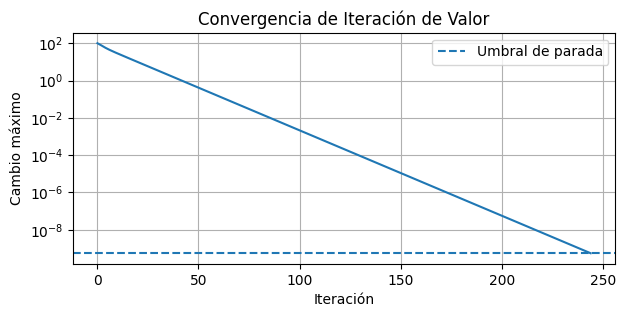

In [6]:
plt.figure(figsize=(7, 3))
plt.semilogy(historial_cambios_generador)
plt.axhline(umbral_generador, linestyle="--", label="Umbral de parada")
plt.xlabel("Iteración")
plt.ylabel("Cambio máximo")
plt.title("Convergencia de Iteración de Valor")
plt.legend()
plt.grid()
plt.show()

## 1.3 Iteración de Política, a mano

`np.linalg.solve` resuelve el paso de evaluación exacta — el mismo cálculo de $(I-\gamma P^\pi)V^\pi=r^\pi$ de la Semana 6, solo que aquí la política cambia de una iteración a la siguiente.

In [7]:
politica_pi_generador = np.zeros(numero_estados_generador, dtype=int)
numero_evaluaciones_generador = 0

inicio_tiempo = time.perf_counter()

while True:

    matriz_politica = np.zeros((numero_estados_generador, numero_estados_generador))
    retorno_politica = np.zeros(numero_estados_generador)

    for estado_actual in range(numero_estados_generador):
        accion_elegida = politica_pi_generador[estado_actual]
        matriz_politica[estado_actual, :] = matrices_generador[accion_elegida][estado_actual, :]
        retorno_politica[estado_actual] = retornos_generador[estado_actual, accion_elegida]

    identidad = np.eye(numero_estados_generador)
    valor_pi_generador = np.linalg.solve(identidad - gamma_generador * matriz_politica, retorno_politica)

    numero_evaluaciones_generador = numero_evaluaciones_generador + 1

    valores_por_accion = np.zeros((numero_estados_generador, numero_acciones_generador))
    for estado_actual in range(numero_estados_generador):
        for accion_actual in range(numero_acciones_generador):
            continuacion = 0.0
            for estado_siguiente in range(numero_estados_generador):
                continuacion = continuacion + matrices_generador[accion_actual][estado_actual, estado_siguiente] * valor_pi_generador[estado_siguiente]
            valores_por_accion[estado_actual, accion_actual] = retornos_generador[estado_actual, accion_actual] + gamma_generador * continuacion

    politica_nueva = np.zeros(numero_estados_generador, dtype=int)
    for estado_actual in range(numero_estados_generador):
        politica_nueva[estado_actual] = np.argmax(valores_por_accion[estado_actual, :])

    politica_estable = True
    for estado_actual in range(numero_estados_generador):
        if politica_nueva[estado_actual] != politica_pi_generador[estado_actual]:
            politica_estable = False

    politica_pi_generador = politica_nueva.copy()

    if politica_estable:
        break

tiempo_pi_generador = (time.perf_counter() - inicio_tiempo) * 1000

print("PI (a mano) convergio en", numero_evaluaciones_generador, "evaluaciones de politica.")
print("Tiempo observado:", round(tiempo_pi_generador, 3), "ms")

PI (a mano) convergio en 3 evaluaciones de politica.
Tiempo observado: 0.714 ms


## 1.4 Confirmación: lo que hicimos a mano es lo que hace `jmarkov`

Resolvemos el mismo `dtmdp` con los dos métodos y comparamos, algoritmo por algoritmo, contra lo que acabamos de programar.

In [8]:
matrices_jmarkov_generador = {
    "Mantener": matrices_generador[0],
    "Reemplazar": matrices_generador[1]
}

mdp_generador = dtmdp(
    estados_generador, acciones_generador, matrices_jmarkov_generador, retornos_generador, gamma_generador
)

valor_vi_jmarkov, politica_vi_jmarkov = mdp_generador.solve(1e-10, minimize=False, method="value_iteration")
valor_pi_jmarkov, politica_pi_jmarkov = mdp_generador.solve(1e-10, minimize=False, method="policy_iteration")

print("V con VI a mano:      ", np.round(valor_vi_generador, 4))
print("V con jmarkov (VI):   ", np.round(np.array(valor_vi_jmarkov, dtype=float), 4))
print("¿Coinciden?           ", np.allclose(valor_vi_generador, valor_vi_jmarkov, atol=1e-3))
print()
print("V con PI a mano:      ", np.round(valor_pi_generador, 4))
print("V con jmarkov (PI):   ", np.round(np.array(valor_pi_jmarkov, dtype=float), 4))
print("¿Coinciden?           ", np.allclose(valor_pi_generador, valor_pi_jmarkov, atol=1e-3))
print()
print("Politica jmarkov:", politica_vi_jmarkov)
print()
print("Actualizaciones de Bellman (VI, a mano):", numero_iteraciones_vi_generador)
print("Evaluaciones de politica (PI, a mano):  ", numero_evaluaciones_generador)

V con VI a mano:       [864.6747 764.4337 744.6747 744.6747]
V con jmarkov (VI):    [864.6747 764.4337 744.6747 744.6747]
¿Coinciden?            True

V con PI a mano:       [864.6747 764.4337 744.6747 744.6747]
V con jmarkov (PI):    [864.6747 764.4337 744.6747 744.6747]
¿Coinciden?            True

Politica jmarkov: {np.str_('Nuevo'): np.str_('Mantener'), np.str_('Bueno'): np.str_('Mantener'), np.str_('Regular'): np.str_('Reemplazar'), np.str_('Malo'): np.str_('Reemplazar')}

Actualizaciones de Bellman (VI, a mano): 245
Evaluaciones de politica (PI, a mano):   3


> **De aquí en adelante, ya no volvemos a escribir el ciclo de VI ni el de PI.** Ya confirmamos que hacen exactamente lo que `dtmdp` hace por dentro; en el resto del cuaderno resolvemos directamente con `jmarkov`, igual que hará usted en el taller y en el proyecto.

---
# Ejercicio 2 — Inventario estacionario

$$
X_t\in\{0,1,2,3,4\}, \qquad a_t\in\{0,1,2,3,4\}, \qquad X_t+a_t\leq 4.
$$

Demanda: $P(D=0)=0.10$, $P(D=1)=0.30$, $P(D=2)=0.40$, $P(D=3)=0.20$.

$$
r(i,a) = -ca + \sum_d P(D=d)\Big[p\min(i+a,d) - h\max(0,i+a-d) - b\max(0,d-i-a)\Big].
$$

Usaremos $p=50$, $c=20$, $h=5$, $b=25$ y $\gamma=0.95$. Lo único que construimos a mano es el **modelo** (retornos y matrices de transición, con ciclos `for`, como siempre); la **solución** la obtenemos directamente de `jmarkov`.

In [9]:
capacidad_inventario = 4
precio_venta = 50
costo_pedido = 20
costo_almacenamiento = 5
costo_escasez = 25
penalizacion_infactible = -100000.0

valores_demanda = np.array([0, 1, 2, 3])
probabilidades_demanda = np.array([0.10, 0.30, 0.40, 0.20])

estados_inventario = np.array(["0", "1", "2", "3", "4"])
# etiquetamos la accion con la cantidad misma que se pide, como un solo caracter:
# simplifica leer despues la politica que devuelve jmarkov (un diccionario por etiqueta)
acciones_inventario = np.array(["0", "1", "2", "3", "4"])

numero_estados_inventario = len(estados_inventario)
numero_acciones_inventario = len(acciones_inventario)

gamma_inventario = 0.95


def construir_retornos_inventario(costo_escasez_modelo):

    retornos = np.zeros((numero_estados_inventario, numero_acciones_inventario))

    for inventario_actual in range(numero_estados_inventario):
        for cantidad_pedida in range(numero_acciones_inventario):

            inventario_disponible = inventario_actual + cantidad_pedida

            if inventario_disponible > capacidad_inventario:
                retornos[inventario_actual, cantidad_pedida] = penalizacion_infactible
            else:
                retorno_esperado = -costo_pedido * cantidad_pedida

                for indice_demanda in range(len(valores_demanda)):
                    demanda = valores_demanda[indice_demanda]
                    probabilidad = probabilidades_demanda[indice_demanda]

                    ventas = min(inventario_disponible, demanda)
                    inventario_final = max(0, inventario_disponible - demanda)
                    demanda_no_atendida = max(0, demanda - inventario_disponible)

                    retorno_demanda = precio_venta * ventas - costo_almacenamiento * inventario_final - costo_escasez_modelo * demanda_no_atendida
                    retorno_esperado = retorno_esperado + probabilidad * retorno_demanda

                retornos[inventario_actual, cantidad_pedida] = retorno_esperado

    return retornos


def construir_transiciones_inventario():

    matrices_por_accion = []

    for cantidad_pedida in range(numero_acciones_inventario):

        matriz_accion = np.zeros((numero_estados_inventario, numero_estados_inventario))

        for inventario_actual in range(numero_estados_inventario):
            inventario_disponible = inventario_actual + cantidad_pedida

            if inventario_disponible > capacidad_inventario:
                matriz_accion[inventario_actual, inventario_actual] = 1.0
            else:
                for indice_demanda in range(len(valores_demanda)):
                    demanda = valores_demanda[indice_demanda]
                    probabilidad = probabilidades_demanda[indice_demanda]
                    inventario_siguiente = max(0, inventario_disponible - demanda)
                    matriz_accion[inventario_actual, inventario_siguiente] = matriz_accion[inventario_actual, inventario_siguiente] + probabilidad

        matrices_por_accion.append(matriz_accion)

    return matrices_por_accion


retornos_inventario = construir_retornos_inventario(costo_escasez)
matrices_inventario = construir_transiciones_inventario()

print("Matriz de retornos:")
print(np.round(retornos_inventario, 2))

print("\nVerificacion de las matrices de transicion:")
for accion_actual in range(numero_acciones_inventario):
    print("\nAccion: pedir", acciones_inventario[accion_actual])
    for estado_actual in range(numero_estados_inventario):
        suma_fila = matrices_inventario[accion_actual][estado_actual, :].sum()
        print("  Estado", estados_inventario[estado_actual], "- suma:", round(float(suma_fila), 6))

Matriz de retornos:
[[    -42.5       4.5      27.5      18.5      -6.5]
 [     24.5      47.5      38.5      13.5 -100000. ]
 [     67.5      58.5      33.5 -100000.  -100000. ]
 [     78.5      53.5 -100000.  -100000.  -100000. ]
 [     73.5 -100000.  -100000.  -100000.  -100000. ]]

Verificacion de las matrices de transicion:

Accion: pedir 0
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Accion: pedir 1
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Accion: pedir 2
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Accion: pedir 3
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0

Accion: pedir 4
  Estado 0 - suma: 1.0
  Estado 1 - suma: 1.0
  Estado 2 - suma: 1.0
  Estado 3 - suma: 1.0
  Estado 4 - suma: 1.0


### Solución con `jmarkov`

Armamos el `dtmdp` y lo resolvemos con los dos métodos, solo para reconfirmar que en este problema más grande también coinciden (ya no hace falta implementarlos a mano para saberlo).

In [10]:
matrices_jmarkov_inventario = {}
for cantidad_pedida in range(numero_acciones_inventario):
    matrices_jmarkov_inventario[acciones_inventario[cantidad_pedida]] = matrices_inventario[cantidad_pedida]

mdp_inventario = dtmdp(
    estados_inventario, acciones_inventario, matrices_jmarkov_inventario, retornos_inventario, gamma_inventario
)

valor_inventario, politica_inventario_vi = mdp_inventario.solve(1e-10, minimize=False, method="value_iteration")
_, politica_inventario_pi = mdp_inventario.solve(1e-10, minimize=False, method="policy_iteration")

print("Valor optimo:")
for estado_actual in range(numero_estados_inventario):
    print("  Inventario", estados_inventario[estado_actual], "->", round(float(valor_inventario[estado_actual]), 4))

print()
print("Politica optima (VI):", politica_inventario_vi)
print("Politica optima (PI):", politica_inventario_pi)
print()
print("¿VI y PI dan la misma politica?", politica_inventario_vi == politica_inventario_pi)

Valor optimo:
  Inventario 0 -> 864.0
  Inventario 1 -> 884.0
  Inventario 2 -> 904.0
  Inventario 3 -> 924.0
  Inventario 4 -> 937.3702

Politica optima (VI): {np.str_('0'): np.str_('3'), np.str_('1'): np.str_('2'), np.str_('2'): np.str_('1'), np.str_('3'): np.str_('0'), np.str_('4'): np.str_('0')}
Politica optima (PI): {np.str_('0'): np.str_('3'), np.str_('1'): np.str_('2'), np.str_('2'): np.str_('1'), np.str_('3'): np.str_('0'), np.str_('4'): np.str_('0')}

¿VI y PI dan la misma politica? True


### Política estacionaria $(s^*,S^*)$

Leemos la política directamente del diccionario que devuelve `jmarkov` — como las etiquetas de acción son la cantidad pedida, `int(politica[estado])` nos da la cantidad sin ninguna traducción adicional.

In [11]:
punto_reorden = -1
nivel_objetivo = -1
estructura_sS = True

print("Politica optima:")

for inventario_actual in range(numero_estados_inventario):

    etiqueta_estado = estados_inventario[inventario_actual]
    cantidad_pedida = int(politica_inventario_vi[etiqueta_estado])
    inventario_despues_pedido = inventario_actual + cantidad_pedida

    print("Inventario", inventario_actual, "-> pedir", cantidad_pedida, "-> nivel despues del pedido:", inventario_despues_pedido)

    if cantidad_pedida > 0:
        punto_reorden = inventario_actual
        if nivel_objetivo == -1:
            nivel_objetivo = inventario_despues_pedido
        elif inventario_despues_pedido != nivel_objetivo:
            estructura_sS = False

print("\n¿La politica tiene estructura (s*, S*)?", estructura_sS)
if estructura_sS and punto_reorden >= 0:
    print("s* =", punto_reorden)
    print("S* =", nivel_objetivo)

Politica optima:
Inventario 0 -> pedir 3 -> nivel despues del pedido: 3
Inventario 1 -> pedir 2 -> nivel despues del pedido: 3
Inventario 2 -> pedir 1 -> nivel despues del pedido: 3
Inventario 3 -> pedir 0 -> nivel despues del pedido: 3
Inventario 4 -> pedir 0 -> nivel despues del pedido: 4

¿La politica tiene estructura (s*, S*)? True
s* = 2
S* = 3


### Sensibilidad al costo de escasez

Cambiar un parámetro puede modificar el valor óptimo sin modificar la acción que alcanza el máximo. Resolvemos dos veces con `jmarkov` — una por cada valor de $b$ — y comparamos.

In [12]:
costo_escasez_alternativo = 40

retornos_inventario_alternativo = construir_retornos_inventario(costo_escasez_alternativo)

matrices_jmarkov_inventario_alt = matrices_jmarkov_inventario  # las transiciones no dependen de b

mdp_inventario_alternativo = dtmdp(
    estados_inventario, acciones_inventario, matrices_jmarkov_inventario_alt, retornos_inventario_alternativo, gamma_inventario
)

valor_alternativo, politica_alternativa = mdp_inventario_alternativo.solve(1e-10, minimize=False, method="value_iteration")

for inventario_actual in range(numero_estados_inventario):

    etiqueta_estado = estados_inventario[inventario_actual]

    print("\nInventario:", inventario_actual)
    print("  Pedido con b=25:", int(politica_inventario_vi[etiqueta_estado]))
    print("  Pedido con b=40:", int(politica_alternativa[etiqueta_estado]))
    print("  Cambio en V*:", round(float(valor_alternativo[inventario_actual] - valor_inventario[inventario_actual]), 4))


Inventario: 0
  Pedido con b=25: 3
  Pedido con b=40: 3
  Cambio en V*: -0.0

Inventario: 1
  Pedido con b=25: 2
  Pedido con b=40: 2
  Cambio en V*: -0.0

Inventario: 2
  Pedido con b=25: 1
  Pedido con b=40: 1
  Cambio en V*: -0.0

Inventario: 3
  Pedido con b=25: 0
  Pedido con b=40: 0
  Cambio en V*: -0.0

Inventario: 4
  Pedido con b=25: 0
  Pedido con b=40: 0
  Cambio en V*: -0.0


---
# Ejercicio abierto — Gestión de flota de vehículos

$$
\mathcal S=\{\text{Óptimo},\text{Funcional},\text{Desgastado},\text{Crítico}\}, \qquad \mathcal A=\{\text{Mantener},\text{Reacondicionar}\}.
$$

$$
P^{(M)}=\begin{pmatrix}0.80&0.20&0&0\\0&0.75&0.25&0\\0&0&0.65&0.35\\0&0&0&1\end{pmatrix}, \qquad P^{(R)}=\begin{pmatrix}1&0&0&0\\0.80&0.20&0&0\\0.80&0.20&0&0\\0.80&0.20&0&0\end{pmatrix}.
$$

La primera fila es ficticia y válida; la acción Reacondicionar desde Óptimo se penaliza con una recompensa de $-10000$.

| Estado | Mantener | Reacondicionar |
|:---|---:|---:|
| Óptimo | 200 | -10000 |
| Funcional | 160 | -80 |
| Desgastado | 100 | -80 |
| Crítico | 40 | -80 |

Use $\gamma=0.92$.

### Actividades

1. Construya `P` como una lista de dos matrices y `R` como una matriz bidimensional.
2. Arme el `dtmdp` y resuélvalo con `method="value_iteration"` y con `method="policy_iteration"`; confirme que dan la misma política.
3. Identifique desde qué estado conviene reacondicionar.
4. Repita con $\gamma=0.75$ y compare la política (no hace falta repetir la implementación manual: use `dtmdp` directamente).
5. **No** vuelva a programar VI ni PI a mano — ya lo hicimos una vez en el Ejercicio 1 y confirmamos que coincide con `jmarkov`; de aquí en adelante, resolver un MDP de horizonte infinito significa construir `P` y `R`, y llamar a `dtmdp.solve`.

## Uso crítico de IA

Antes de aceptar el código generado, compruebe:

$$
R[\text{Funcional},\text{Reacondicionar}] = 200-280 = -80.
$$

También verifique que:

- todas las filas de las matrices de transición sumen 1;
- la primera fila de Reacondicionar sea `[1, 0, 0, 0]`;
- el código resuelve con `dtmdp`, no con una reimplementación manual de VI o PI (eso ya se hizo una vez, en el Ejercicio 1).

### Prompt sugerido

```text
Estoy resolviendo un MDP de horizonte infinito en Python. Ya programe VI y PI
a mano una vez, en un ejercicio anterior, y confirme que coinciden con
jmarkov. De aqui en adelante quiero resolver directamente con jmarkov.

Ayudame a construir los arreglos del ejercicio de flota: los estados, las
acciones, las dos matrices de transicion (como una lista) y la matriz de
retornos bidimensional. Usa solamente ciclos for, condicionales y arreglos de
NumPy para esa construccion (sin zip, enumerate ni comprensiones).

Con esos arreglos, arma un objeto dtmdp y resuelvelo con
method="value_iteration" y con method="policy_iteration". Compara que las dos
politicas coincidan. Comprueba que R[Funcional, Reacondicionar] sea -80 y que
todas las filas de las matrices de transicion sumen 1.
```

In [13]:
# Desarrolle aqui el ejercicio abierto.
# Construya los estados, las acciones, las dos matrices de transicion
# y la matriz de retornos; despues arme el dtmdp y resuelvalo
# directamente (no reimplemente VI ni PI a mano).

---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>